1. Dynamic Clinical Pathway Generation Complete.
>> Displaying Visualizations (Close the first window to see the second...)


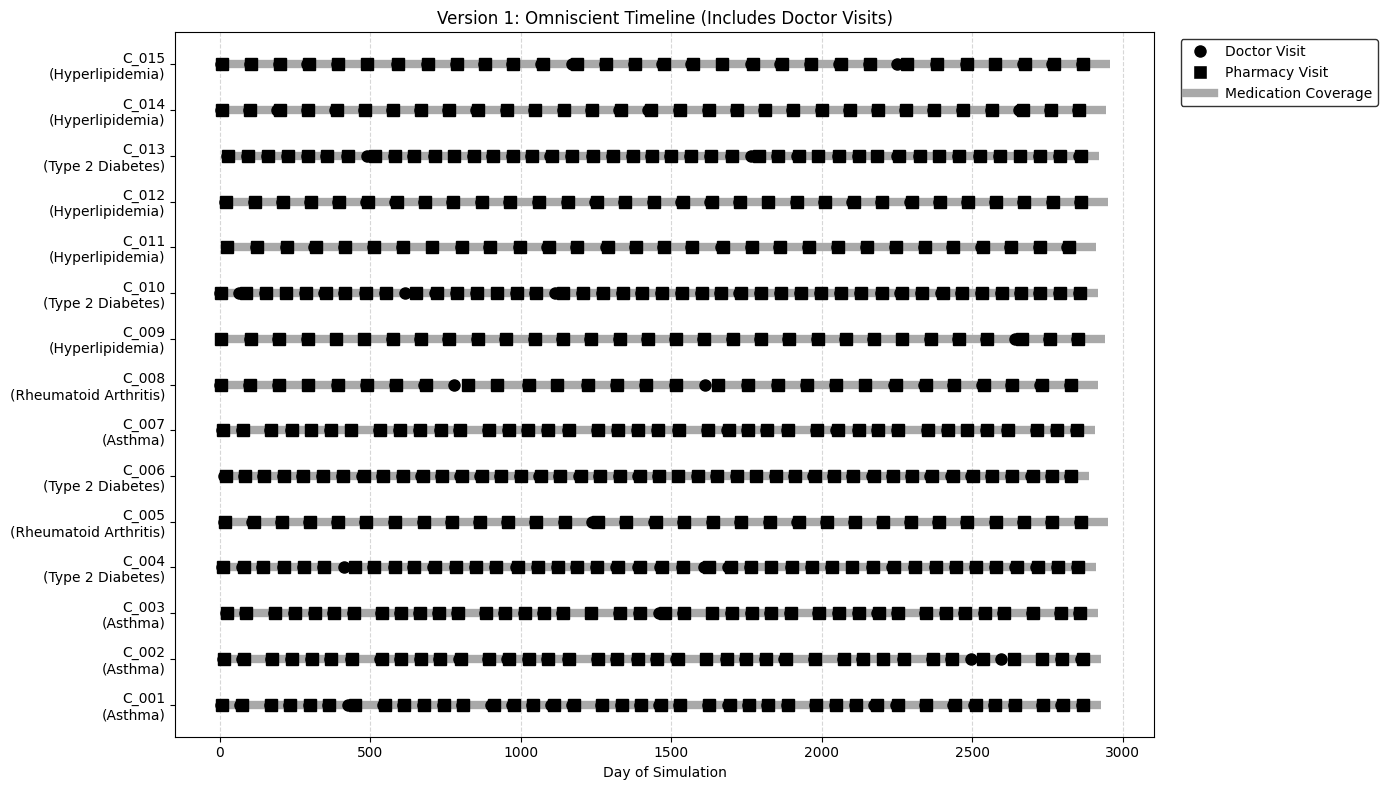

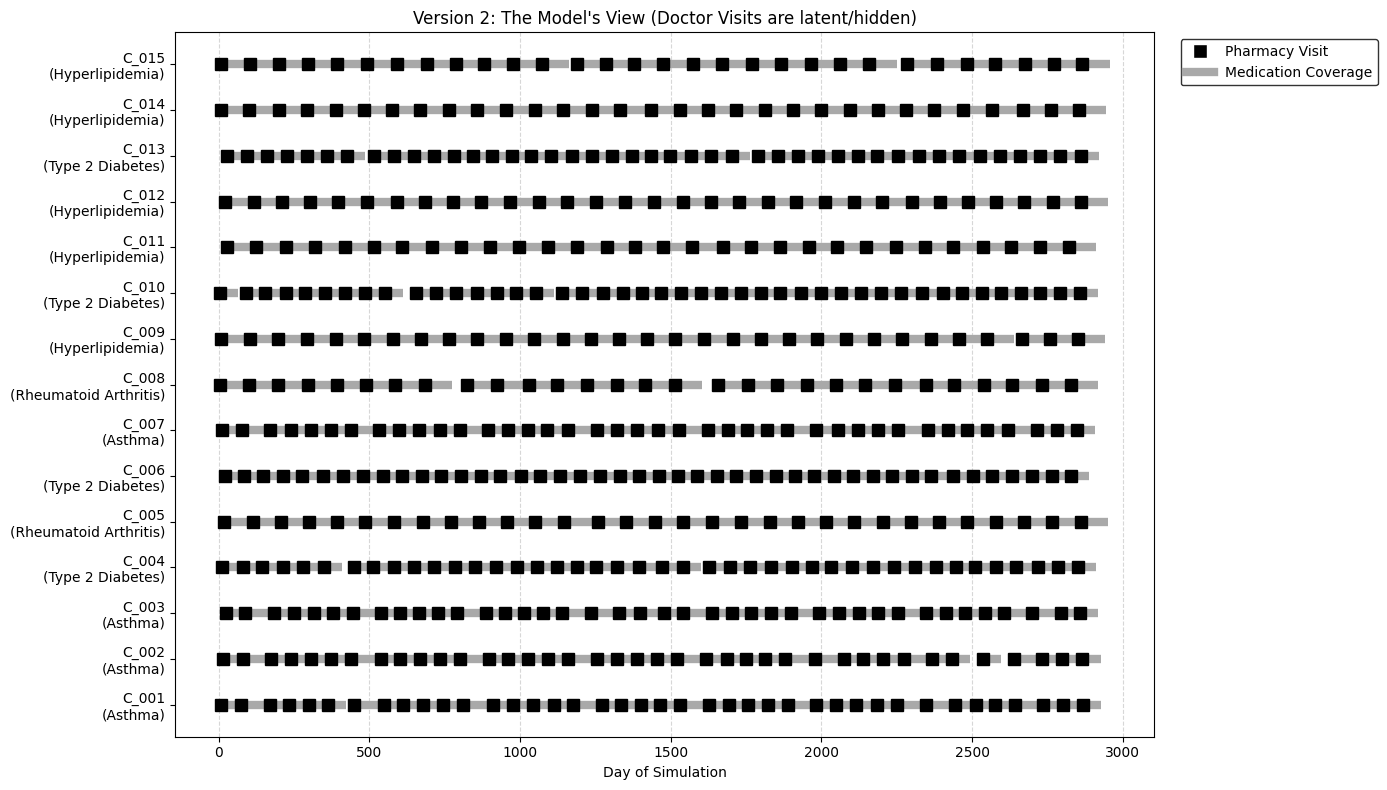

2. Formatting Sequence History [visit_{t-k, t} -> visit_{t+1}]...

--- Example Sequence Output (Row 0) ---
Client: C_001 (Asthma)
History Window (t-k to t):
  Step 1: Gap = 0.0 days | Meds = ['Inhaled Corticosteroid']
Target (t+1):
  Gap = 7.0 days | Meds = ['Inhaled Corticosteroid', 'Albuterol Rescue', 'Leukotriene Modifier']

>> Disease Mask Created: torch.Size([5, 16]) (Diseases x Meds)
3. Data split complete. Train Rows: 29213 | Test Rows: 9075


In [1]:
import sys
import os
parent_dir = os.path.join('..', os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from module.data_generator import ClinicalSimulationPipeline
from module.model import StatisticalBaseline, VAEGenerativeModel, BaselineLSTM, calc_iou_batch
# ==========================================
# 3. CALLING SCRIPT
# ==========================================

pipeline = ClinicalSimulationPipeline(
    n_clients=1000, 
    simulation_days=12 * 30 * 8, 
    split_day=12 * 30 * 6 + 12 * 2
)

# 2. Run the Generation Phase
pipeline.generate_pathways()

# 3. View the Visualizations 
# (Will halt execution until the plot windows are closed)
pipeline.visualize(sample_size=15)

# 4. Preprocess Data and build time-series sequences
pipeline.preprocess_sequences(seq_len=10)

# 5. Build ML Tensor Mappings / Masks
pipeline.create_mappings()

# Example to fetch internal data for further PyTorch DataLoader use:
train_seq_df = pipeline.train_seq_df
test_seq_df = pipeline.test_seq_df
disease_mask = pipeline.disease_mask
disease_to_idx = pipeline.disease_to_idx
all_meds = pipeline.all_meds
disease_names = pipeline.disease_names


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
# ==========================================
# 3. PYTORCH DATASET & DATALOADERS
# ==========================================
class ClinicalDataset(Dataset):
    def __init__(self, df, all_meds, disease_to_idx, max_gap=100.0, seq_len=10):
        self.df = df.reset_index(drop=True)
        self.all_meds = all_meds
        self.med_to_idx = {m: i for i, m in enumerate(all_meds)}
        self.disease_to_idx = disease_to_idx
        self.max_gap = max_gap
        self.num_meds = len(all_meds)
        self.seq_len = seq_len

    def __len__(self): return len(self.df)

    def encode_meds(self, med_list):
        vec = torch.zeros(self.num_meds)
        for m in med_list:
            if m in self.med_to_idx: vec[self.med_to_idx[m]] = 1.0
        return vec

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        c_idx = torch.tensor(self.disease_to_idx[row['disease']], dtype=torch.long)
        
        x_seq = []
        for visit in row['history_window']:
            med_vec = self.encode_meds(visit['meds'])
            # FIX: Properly scale the supply duration (m_days) so 60 becomes 0.6
            duration_val = torch.tensor([visit['m_days'] / self.max_gap], dtype=torch.float32)
            x_seq.append(torch.cat([med_vec, duration_val]))
            
        x_seq = torch.stack(x_seq)
        
        # Zero Padding for sequences shorter than seq_len
        pad_len = self.seq_len - x_seq.shape[0]
        if pad_len > 0:
            padding = torch.zeros((pad_len, self.num_meds + 1), dtype=torch.float32)
            x_seq = torch.cat([padding, x_seq], dim=0)
            
        y_meds = self.encode_meds(row['target']['meds'])
        # Target Gap is also scaled
        y_gap = torch.tensor([row['target']['M_gap'] / self.max_gap], dtype=torch.float32)
        
        return x_seq, c_idx, y_meds, y_gap, row['client_id'], row['target_pharmacy_day']

train_dataset = ClinicalDataset(train_seq_df, all_meds, disease_to_idx, seq_len=10)
test_dataset = ClinicalDataset(test_seq_df, all_meds, disease_to_idx, seq_len=10)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


[1/3] Training Baseline LSTM...
[Baseline LSTM] Epoch 10 Loss: 0.0725
[Baseline LSTM] Epoch 20 Loss: 0.0717

[2/3] Training VAE Generative Model...

[3/3] Training Statistical Baseline (Logistic + Ridge AR)...
[Statistical Baseline] Fitting Multi-Output Logistic Regression for Meds...
[Statistical Baseline] Fitting AR (Ridge) model for Day Gaps...
[Statistical Baseline] Training Complete.

Generating predictions across all 6 configurations...

FINAL PERFORMANCE COMPARISON

Statistical Baseline (Unmasked):
  IoU Accuracy : 93.19%
  Day Error    : ±2.83 Days

Statistical Baseline (Masked):
  IoU Accuracy : 93.19%
  Day Error    : ±2.83 Days

Baseline LSTM (Unmasked):
  IoU Accuracy : 98.75%
  Day Error    : ±3.01 Days

Baseline LSTM (Masked):
  IoU Accuracy : 98.75%
  Day Error    : ±3.01 Days

VAE Generative (Unmasked):
  IoU Accuracy : 98.75%
  Day Error    : ±2.82 Days

VAE Generative (Masked):
  IoU Accuracy : 98.75%
  Day Error    : ±2.82 Days

Rendering 6-panel comparison plot for

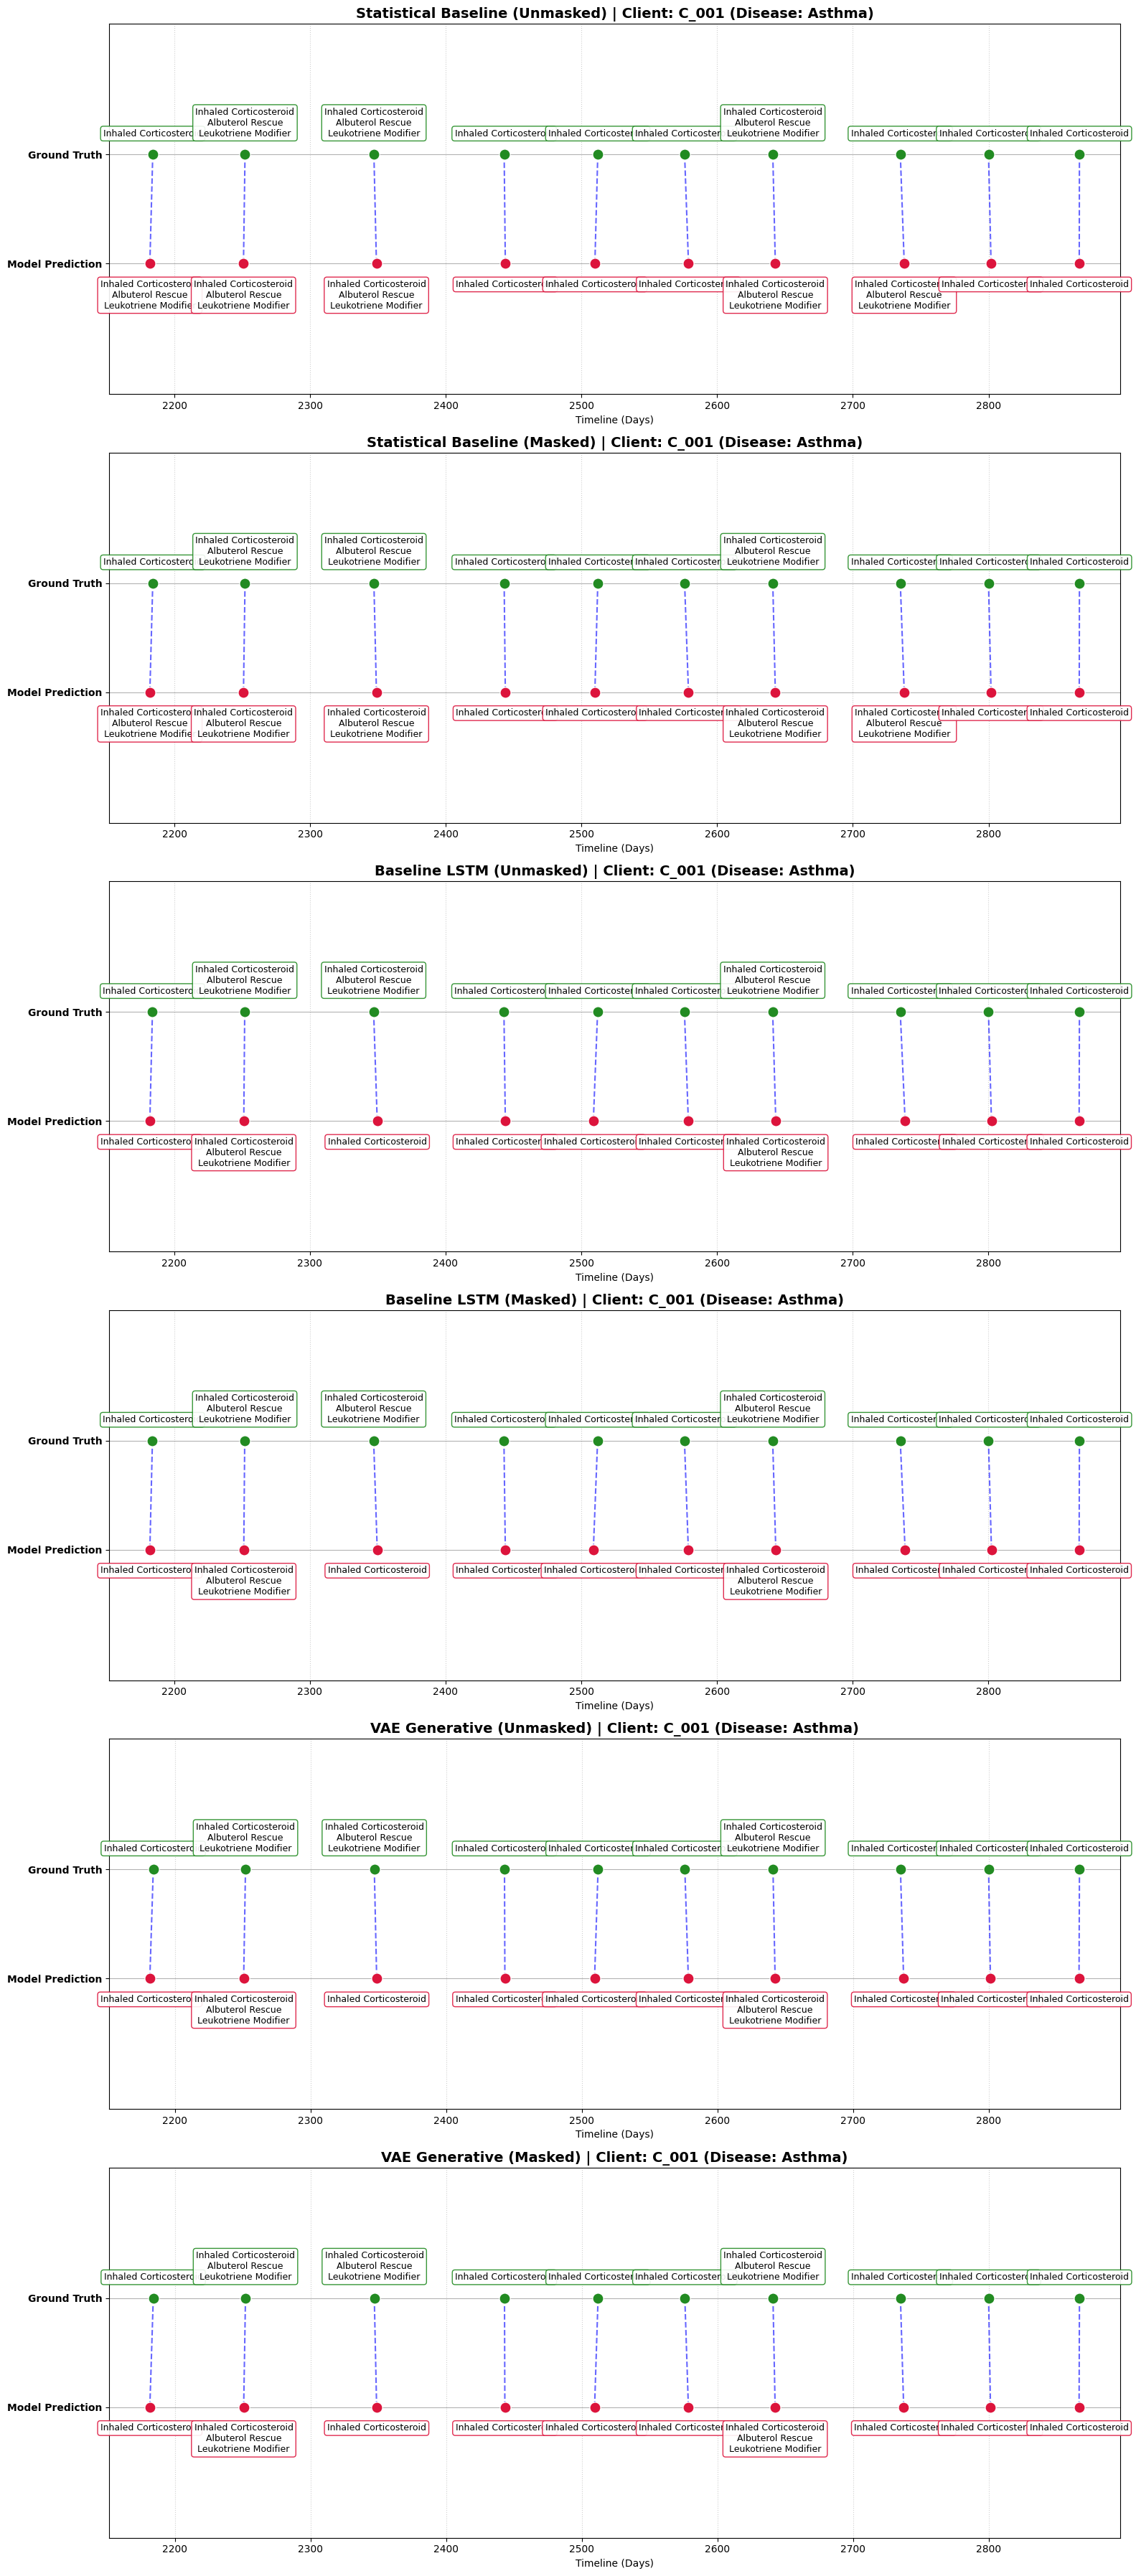

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
def plot_client_comparison(client_id, configs, test_df, all_meds):
    """
    Visualizes medication and timing predictions dynamically based on provided configs.
    configs format: [(results_tuple, "Plot Title"), ...]
    """
    num_plots = len(configs)
    fig, axes = plt.subplots(num_plots, 1, figsize=(16, 6 * num_plots), sharex=False)
    
    # Ensure axes is iterable even if there's only 1 plot
    if num_plots == 1:
        axes = [axes]
        
    client_data = test_df[test_df['client_id'] == client_id]
    if client_data.empty:
        return print(f"Client {client_id} not found in dataset.")
    
    disease = client_data['disease'].iloc[0]
        
    for ax, (results, title) in zip(axes, configs):
        pm, tm, pg, tg, cids, tdays = results
        
        mask = (cids == client_id)
        if not mask.any():
            ax.set_title(f"{title}: No data found for ID {client_id}")
            continue
            
        c_pm, c_tm, c_pg, c_tg, c_tdays = pm[mask], tm[mask], pg[mask], tg[mask], tdays[mask]
        
        sort_idx = np.argsort(c_tdays)
        c_pm, c_tm, c_pg, c_tg, c_tdays = c_pm[sort_idx], c_tm[sort_idx], c_pg[sort_idx], c_tg[sort_idx], c_tdays[sort_idx]
        
        plot_t_days, plot_p_days, text_t_meds, text_p_meds = [], [], [], []
        
        for i in range(len(c_tdays)):
            t_day = c_tdays[i]
            true_gap = c_tg[i].item()
            pred_gap = c_pg[i].item()
            
            plot_t_days.append(t_day)
            plot_p_days.append((t_day - true_gap) + pred_gap)
            
            # Predict medications (Sigmoid > 0.5 threshold logic)
            p_probs = torch.sigmoid(c_pm[i])
            p_idx = (p_probs > 0.5).nonzero(as_tuple=False).squeeze(-1)
            text_p_meds.append("\n".join([all_meds[idx] for idx in p_idx]) or "None")
            
            t_idx = c_tm[i].nonzero(as_tuple=False).squeeze(-1)
            text_t_meds.append("\n".join([all_meds[idx] for idx in t_idx]) or "None")

        ax.set_title(f"{title} | Client: {client_id} (Disease: {disease})", fontweight='bold', fontsize=14)
        ax.axhline(1, color='black', linewidth=0.8, alpha=0.3, zorder=1)
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.3, zorder=1)
        
        for i in range(len(plot_t_days)):
            color = 'blue' if abs(plot_t_days[i] - plot_p_days[i]) < 5 else 'orange'
            ax.plot([plot_t_days[i], plot_p_days[i]], [1, 0], color=color, linestyle='--', alpha=0.6, zorder=2)
            
            ax.scatter(plot_t_days[i], 1, color='forestgreen', s=120, edgecolors='white', zorder=3, label='Actual' if i==0 else "")
            ax.text(plot_t_days[i], 1.15, text_t_meds[i], ha='center', va='bottom', fontsize=9, 
                    bbox=dict(facecolor='white', edgecolor='forestgreen', alpha=0.9, boxstyle='round,pad=0.3'))
            
            ax.scatter(plot_p_days[i], 0, color='crimson', s=120, edgecolors='white', zorder=3, label='Predicted' if i==0 else "")
            ax.text(plot_p_days[i], -0.15, text_p_meds[i], ha='center', va='top', fontsize=9, 
                    bbox=dict(facecolor='white', edgecolor='crimson', alpha=0.9, boxstyle='round,pad=0.3'))

        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Model Prediction', 'Ground Truth'], fontweight='bold')
        ax.set_ylim(-1.2, 2.2) 
        ax.set_xlabel("Timeline (Days)", fontsize=10)
        ax.grid(axis='x', linestyle=':', alpha=0.6)
        
        all_x = plot_t_days + plot_p_days
        ax.set_xlim(min(all_x) - 30, max(all_x) + 30)

    plt.tight_layout()
    plt.show()
# ==========================================
# 5. EXECUTION & VISUALIZATION (ALL PERMUTATIONS)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_DIM = len(pipeline.all_meds) + 1  # Using the pipeline attributes

# --- 1. TRAIN MODELS (Unconstrained / Without Masks) ---
lstm_model = BaselineLSTM(INPUT_DIM, len(pipeline.disease_names), len(pipeline.all_meds), pipeline.disease_mask)
print("\n[1/3] Training Baseline LSTM...")
lstm_model.fit(train_loader, epochs=20, device=device)

vae_model = VAEGenerativeModel(INPUT_DIM, len(pipeline.disease_names), len(pipeline.all_meds), pipeline.disease_mask)
print("\n[2/3] Training VAE Generative Model...")
vae_model.fit(train_loader, epochs=20, device=device)

stat_model = StatisticalBaseline(pipeline.disease_mask)
print("\n[3/3] Training Statistical Baseline (Logistic + Ridge AR)...")
stat_model.fit(train_loader, device=device)

# --- 2. PREDICT (Every Model: With and Without Masks) ---
print("\nGenerating predictions across all 6 configurations...")

# A. Statistical Baseline
res_stat_unmask = stat_model.predict(test_loader, device=device, apply_mask=False)
res_stat_masked  = stat_model.predict(test_loader, device=device, apply_mask=True)

# B. Baseline LSTM
res_lstm_unmask = lstm_model.predict(test_loader, device=device, apply_mask=False)
res_lstm_masked  = lstm_model.predict(test_loader, device=device, apply_mask=True)

# C. Split-Head Diffusion
res_vae_unmask = vae_model.predict(test_loader, device=device, gen_num=10, apply_mask=False)
res_vae_masked = vae_model.predict(test_loader, device=device, gen_num=10, apply_mask=True)
# --- 3. COMPARE METRICS ---
eval_configs = [
    ("Statistical Baseline (Unmasked)", res_stat_unmask),
    ("Statistical Baseline (Masked)", res_stat_masked),
    ("Baseline LSTM (Unmasked)", res_lstm_unmask),
    ("Baseline LSTM (Masked)", res_lstm_masked),
    ("VAE Generative (Unmasked)", res_vae_unmask),
    ("VAE Generative (Masked)", res_vae_masked)
]

print("\n" + "="*40)
print("FINAL PERFORMANCE COMPARISON")
print("="*40)
for name, res in eval_configs:
    iou = calc_iou_batch(res[0], res[1])
    err = torch.abs(res[2] - res[3]).mean().item()
    print(f"\n{name}:")
    print(f"  IoU Accuracy : {iou:.2%}")
    print(f"  Day Error    : ±{err:.2f} Days")

# --- 4. PLOT ---
# Reorganize configs for the dynamic plotting function
plot_configs = [(res, name) for name, res in eval_configs]

asthma_clients = pipeline.test_seq_df[pipeline.test_seq_df['disease'] == 'Asthma']['client_id'].unique()

# Plot all 6 setups stacked for the first Asthma client
print(f"\nRendering 6-panel comparison plot for client {asthma_clients[0]}...")
plot_client_comparison(asthma_clients[0], plot_configs, pipeline.test_seq_df, pipeline.all_meds)


MASKED MODELS: BEST, MEDIAN, WORST CLIENT ANALYSIS

--- Statistical Baseline (Masked) ---
🏆 BEST Client   : C_667 | IoU: 100.00% | Err: ±0.53 Days
📊 MEDIAN 1 Client: C_062 | IoU: 100.00% | Err: ±4.01 Days
📊 MEDIAN 2 Client: C_999 | IoU: 100.00% | Err: ±4.03 Days
📊 MEDIAN 3 Client: C_732 | IoU: 100.00% | Err: ±4.04 Days
🚨 WORST Client  : C_277 | IoU: 64.29% | Err: ±6.69 Days


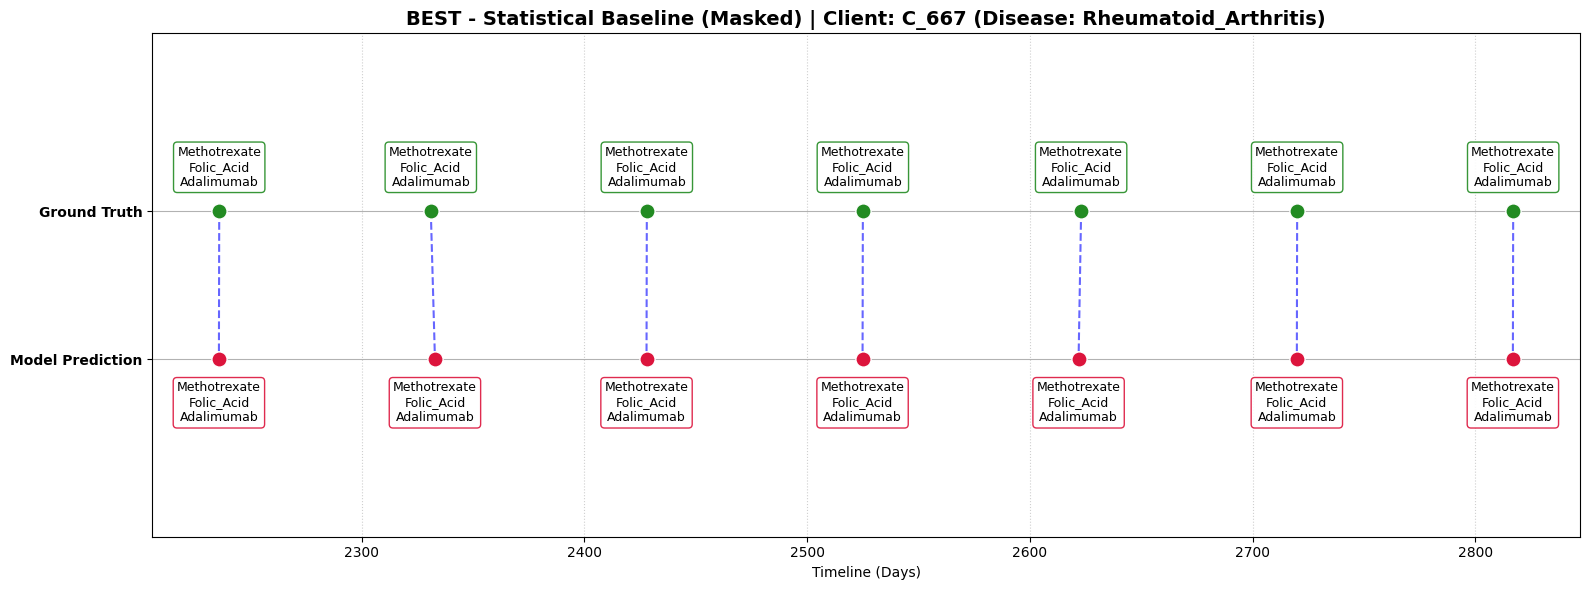

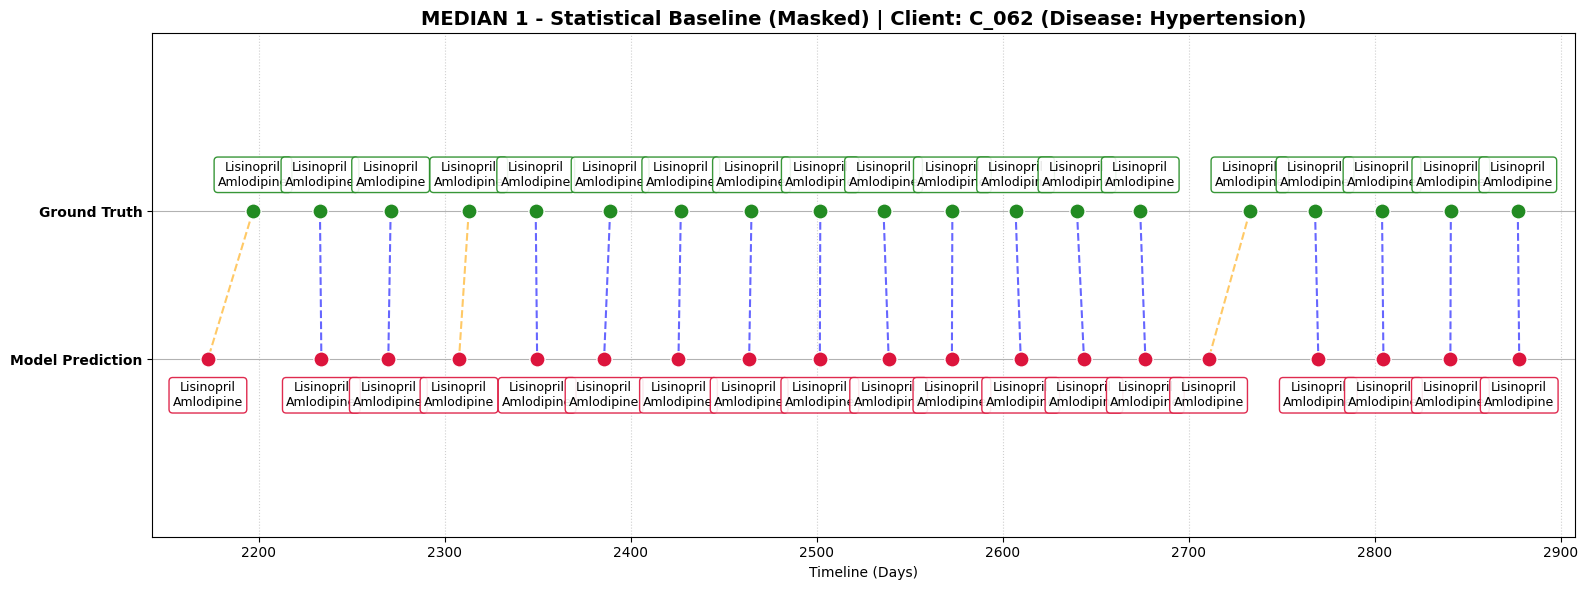

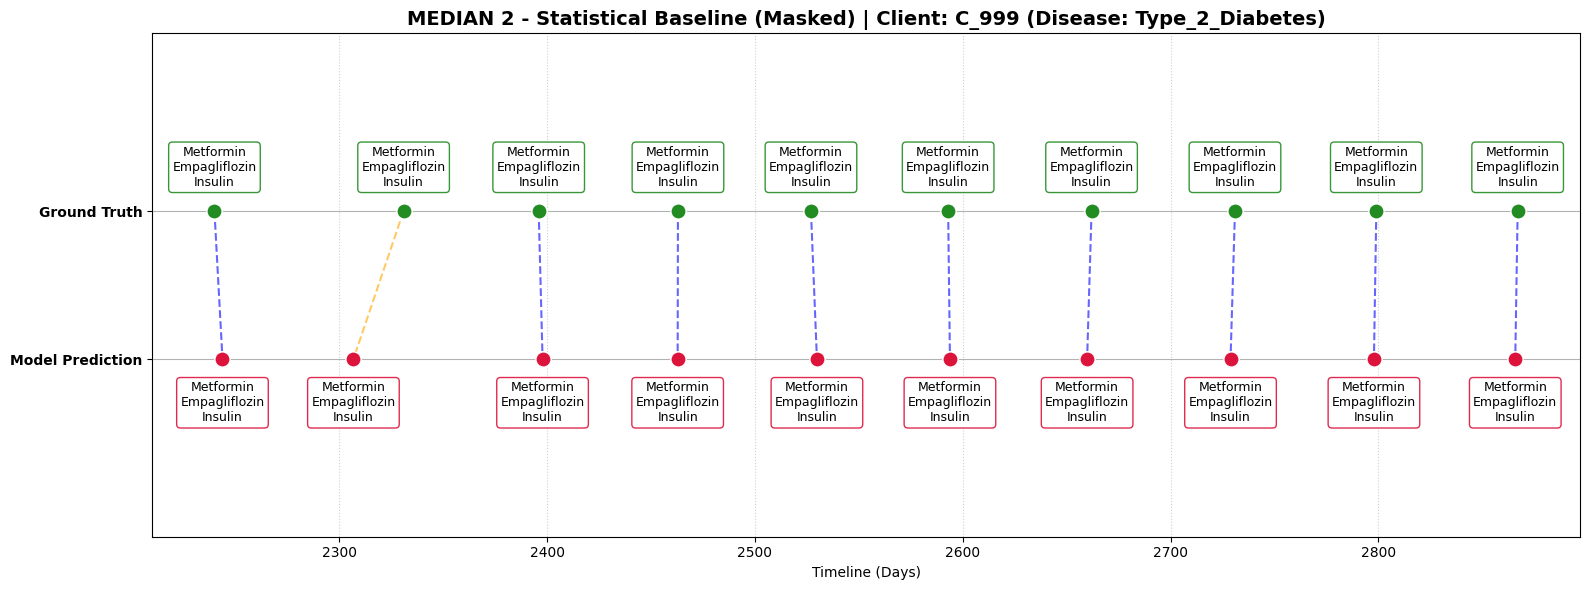

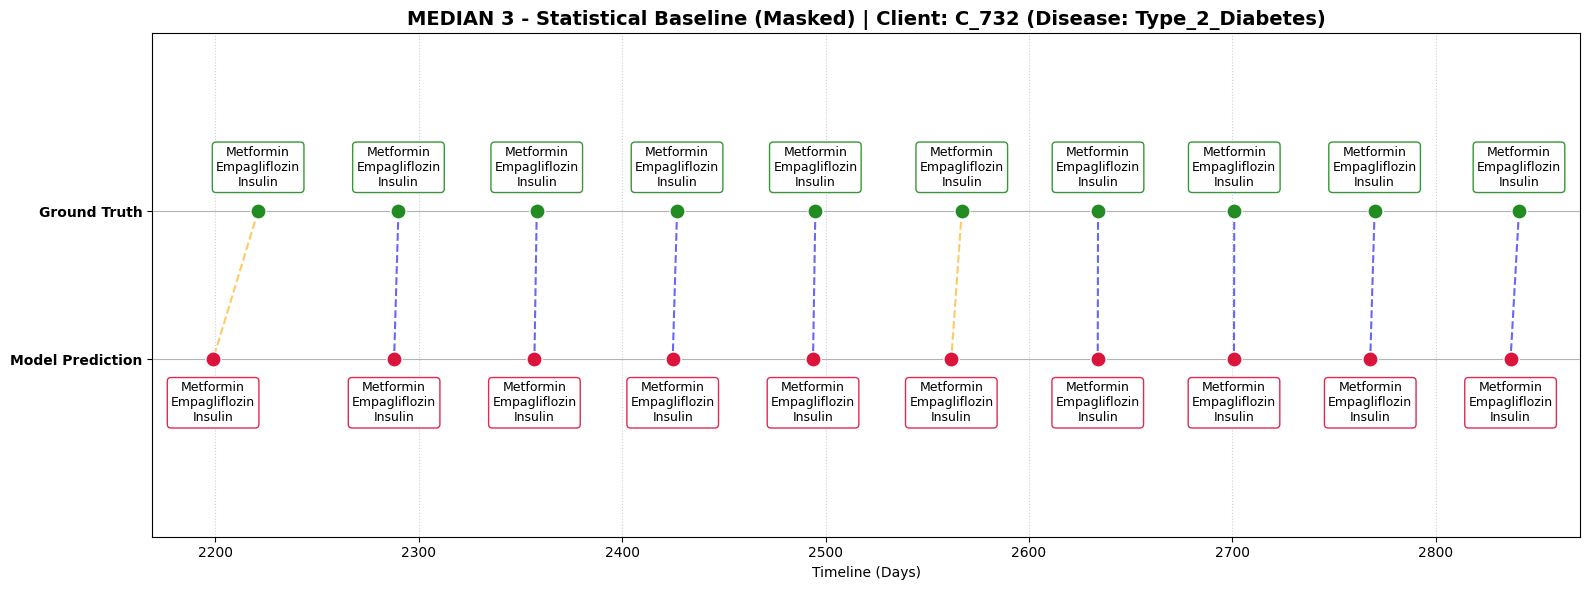

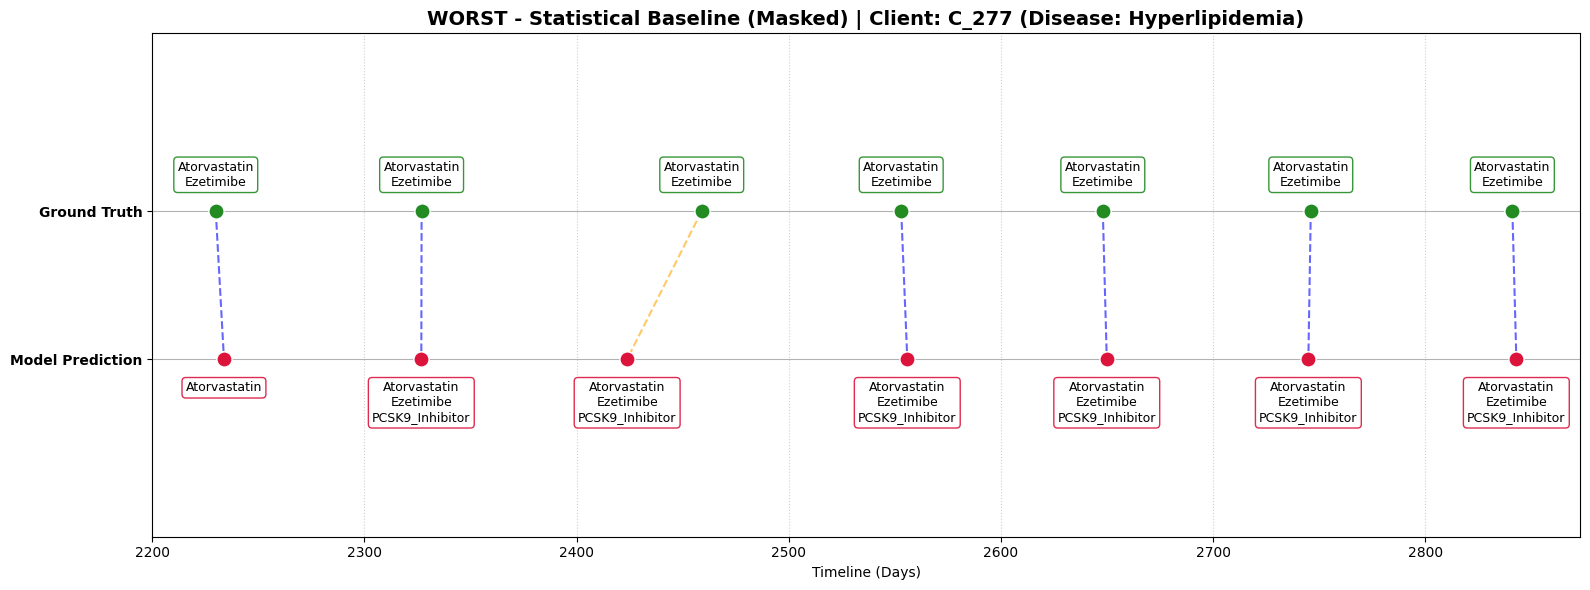


--- Baseline LSTM (Masked) ---
🏆 BEST Client   : C_667 | IoU: 100.00% | Err: ±0.73 Days
📊 MEDIAN 1 Client: C_427 | IoU: 100.00% | Err: ±2.74 Days
📊 MEDIAN 2 Client: C_730 | IoU: 100.00% | Err: ±2.74 Days
📊 MEDIAN 3 Client: C_222 | IoU: 100.00% | Err: ±2.74 Days
🚨 WORST Client  : C_327 | IoU: 71.43% | Err: ±8.38 Days


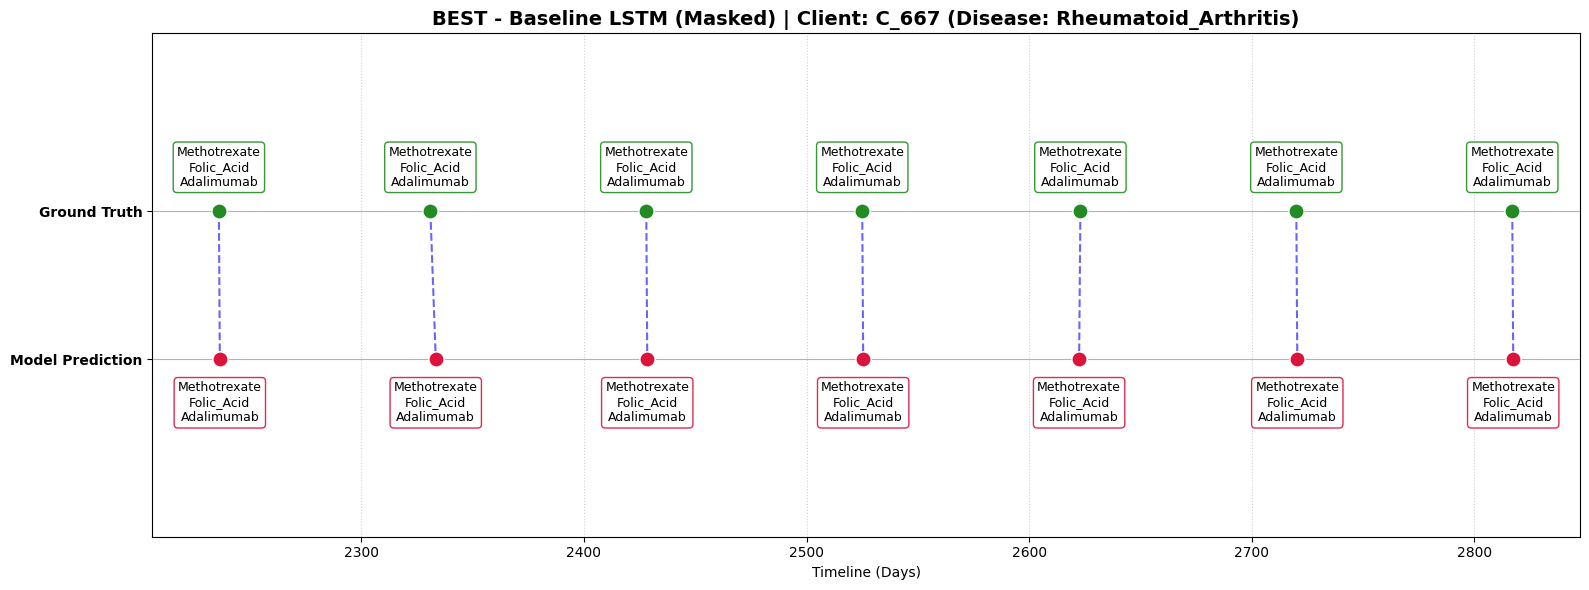

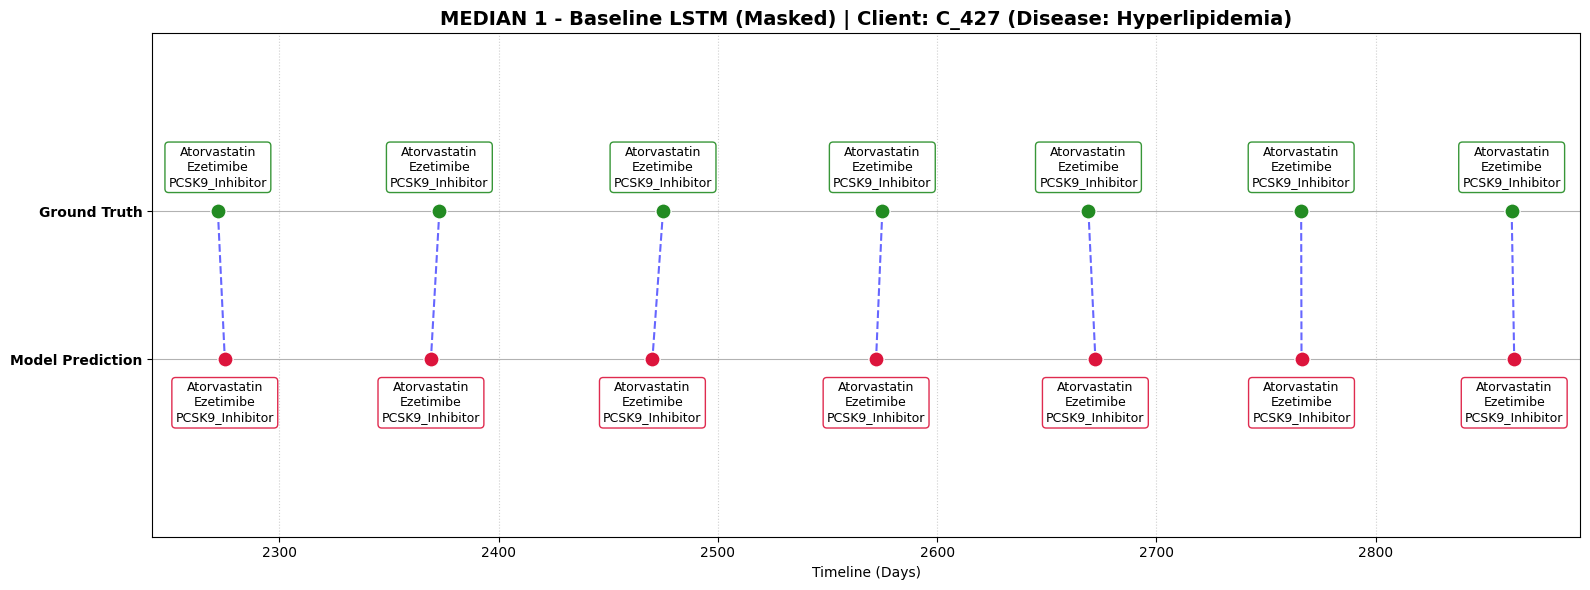

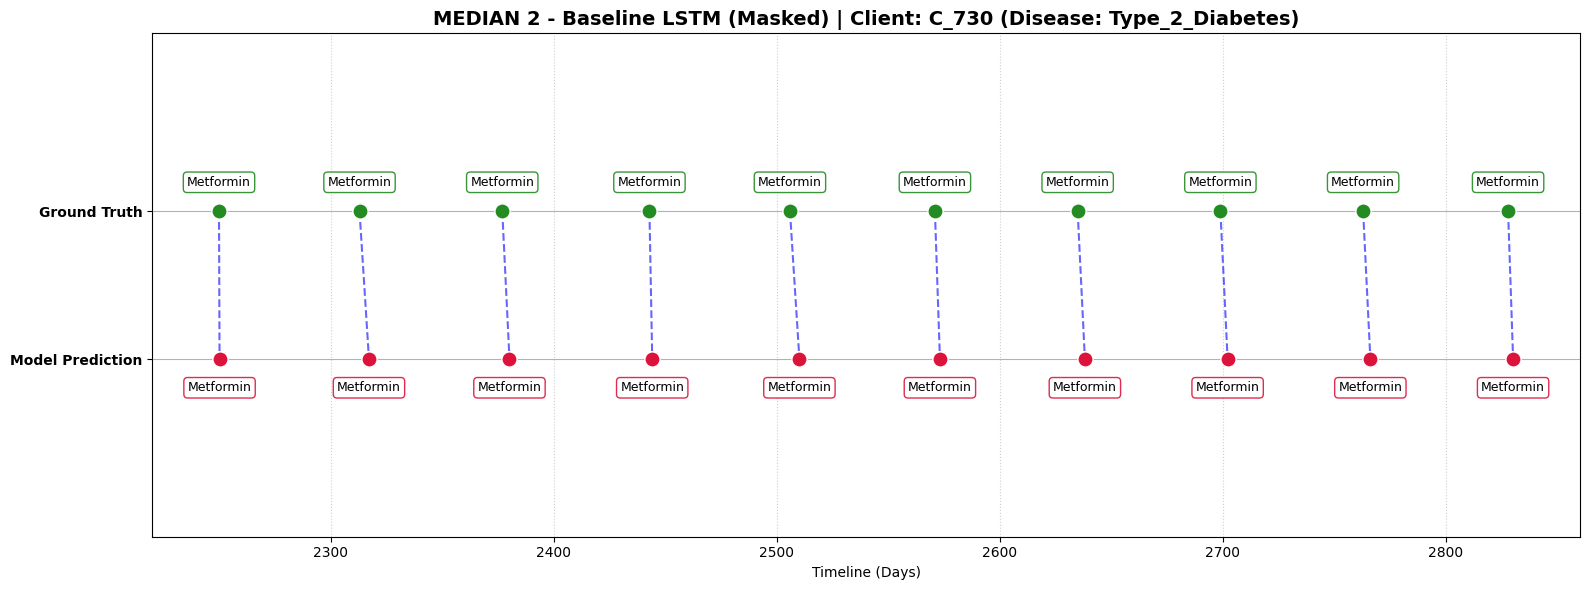

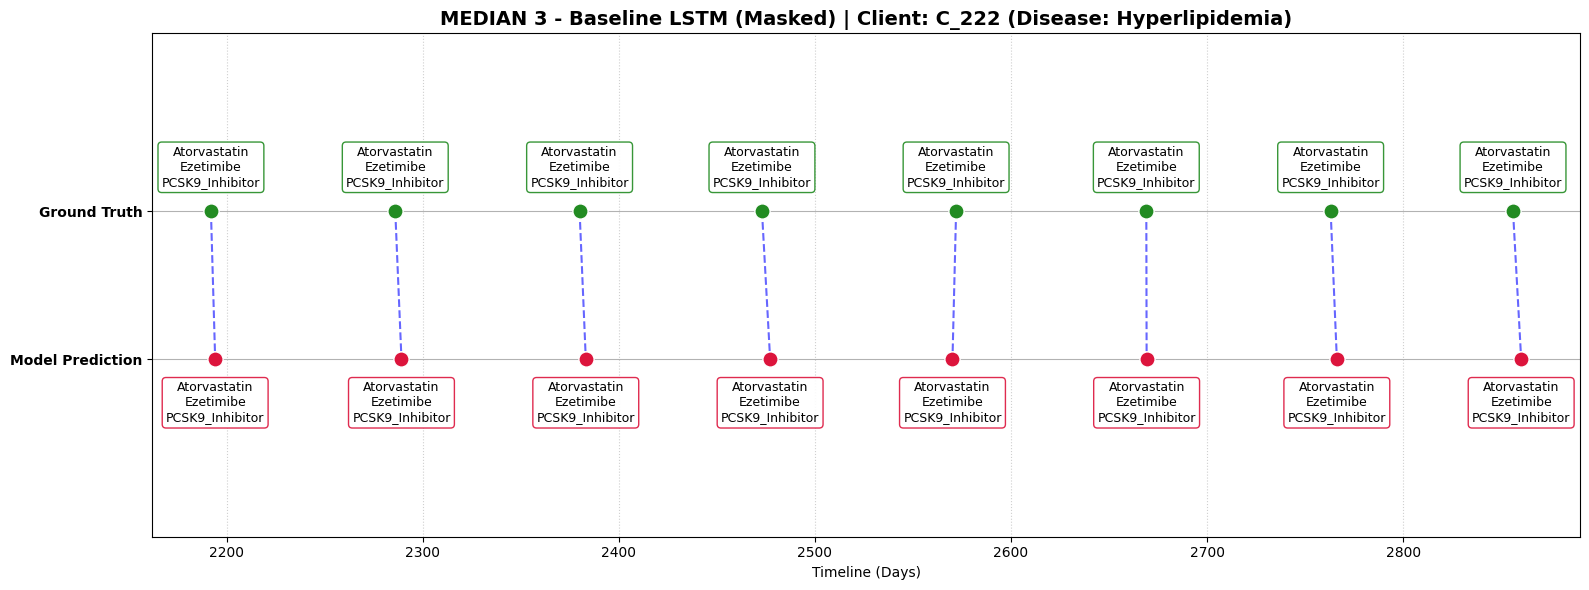

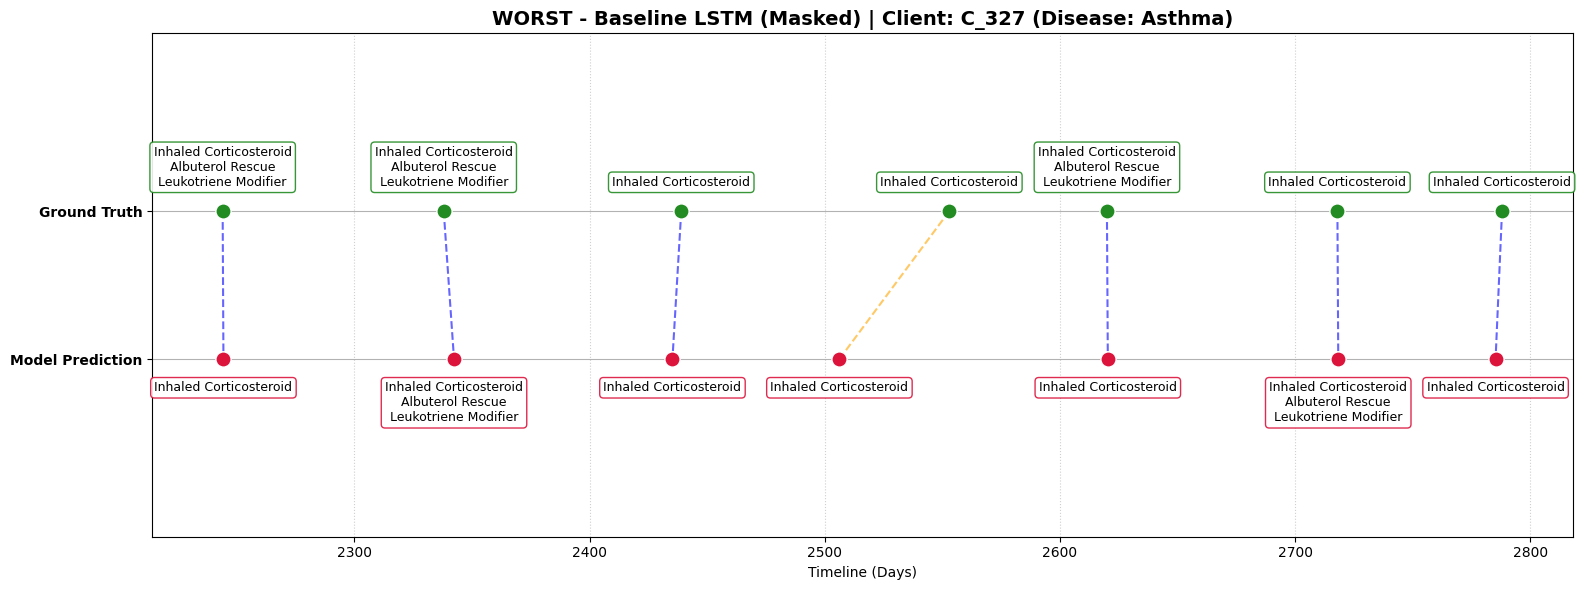


--- VAE Generative (Masked) ---
🏆 BEST Client   : C_975 | IoU: 100.00% | Err: ±0.68 Days
📊 MEDIAN 1 Client: C_050 | IoU: 100.00% | Err: ±2.49 Days
📊 MEDIAN 2 Client: C_140 | IoU: 100.00% | Err: ±2.50 Days
📊 MEDIAN 3 Client: C_104 | IoU: 100.00% | Err: ±2.50 Days
🚨 WORST Client  : C_327 | IoU: 71.43% | Err: ±8.37 Days


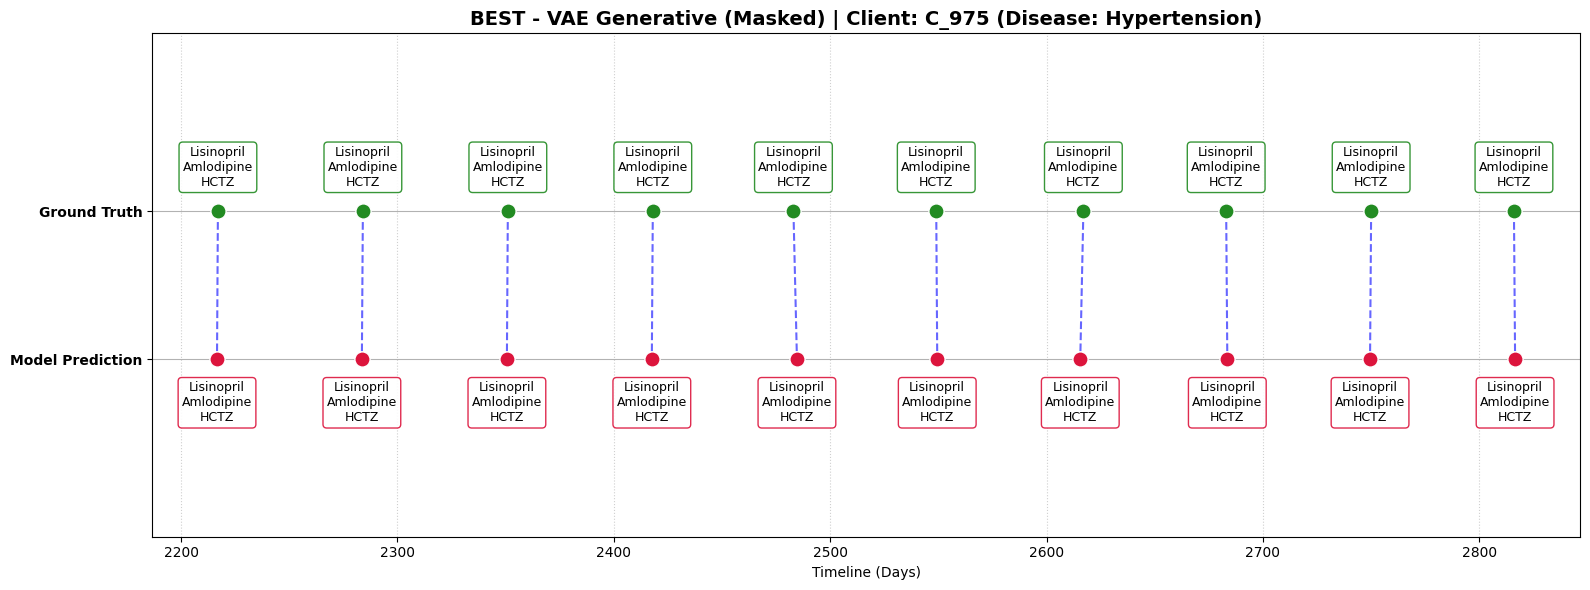

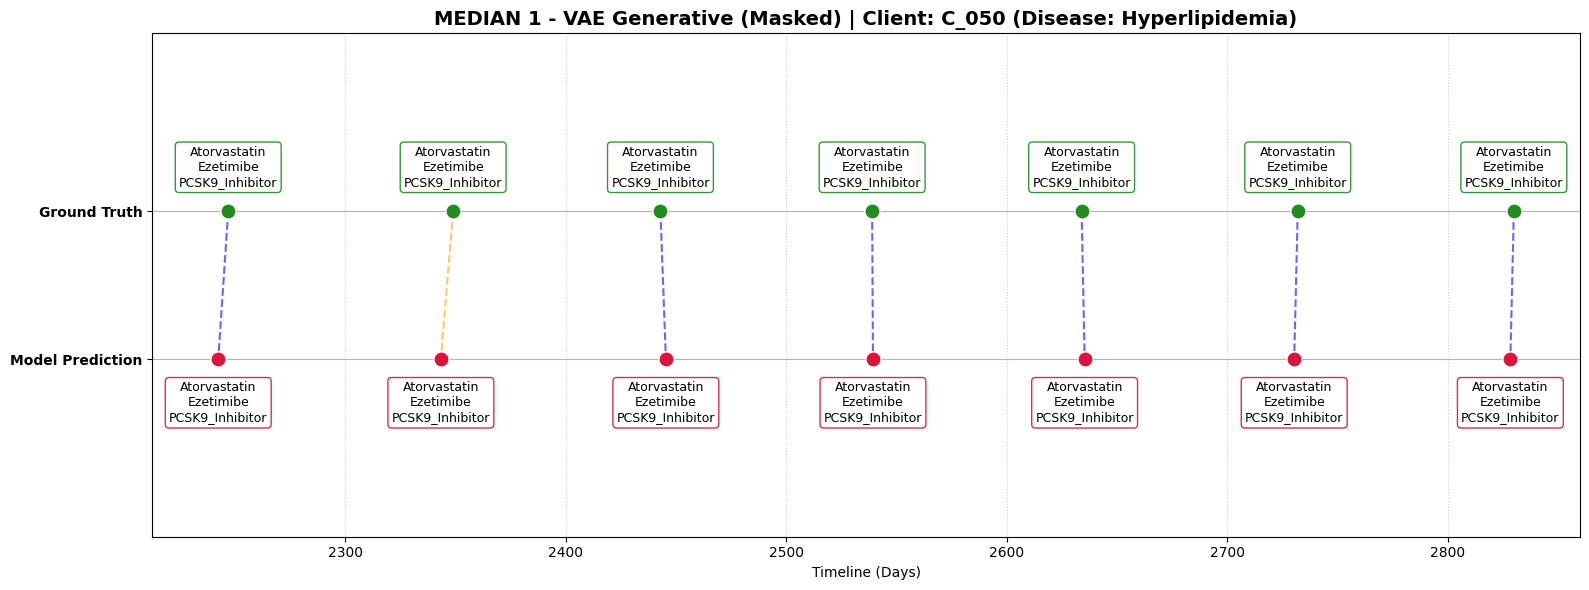

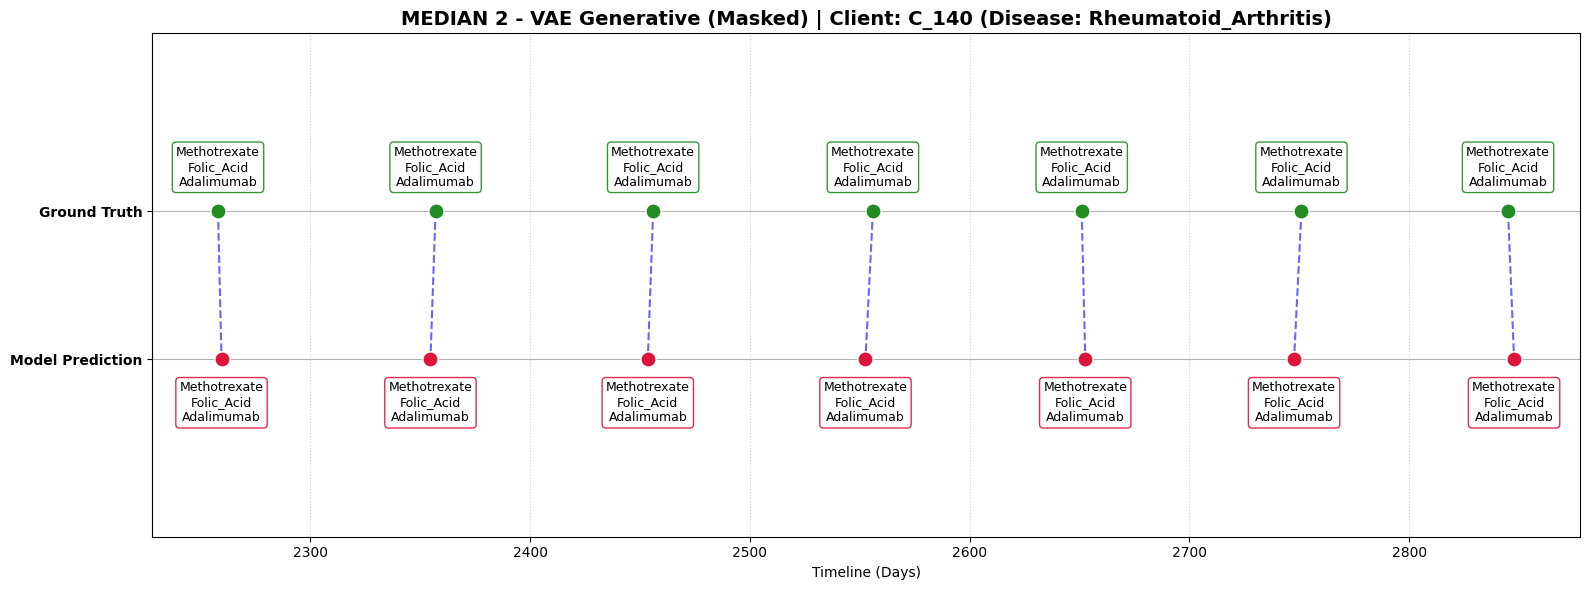

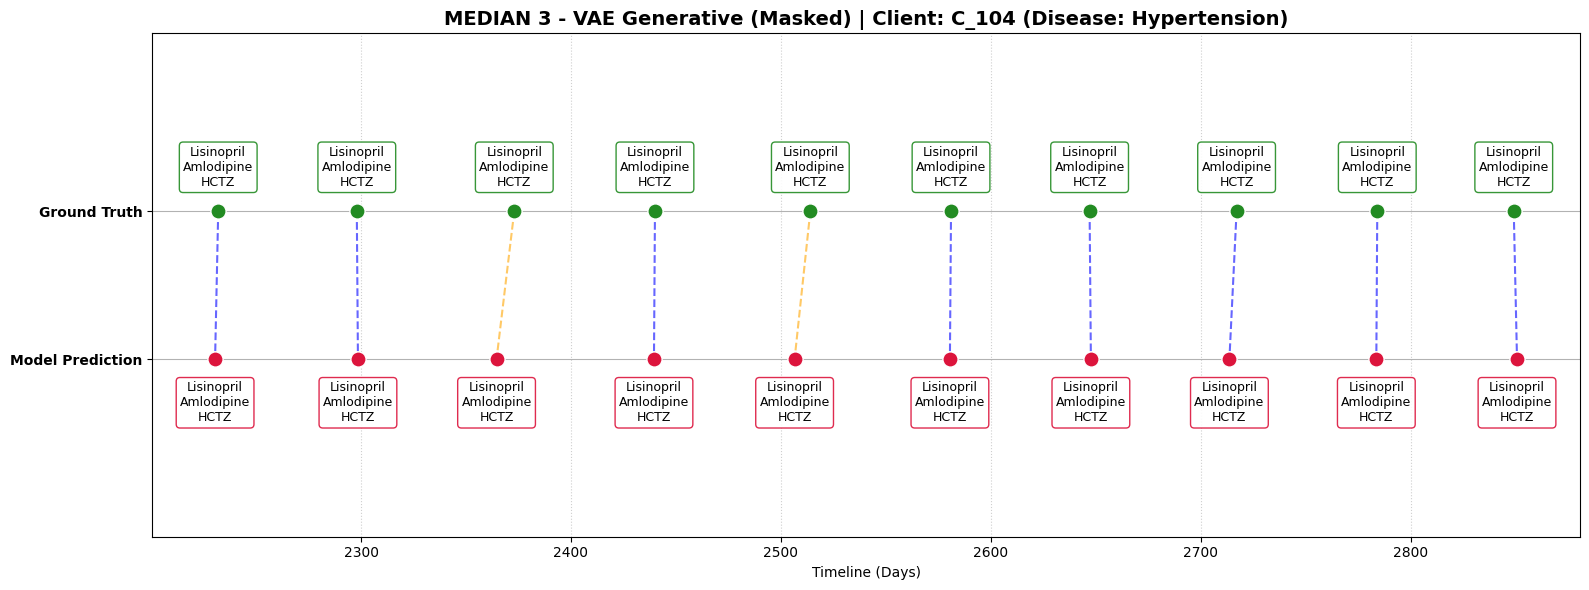

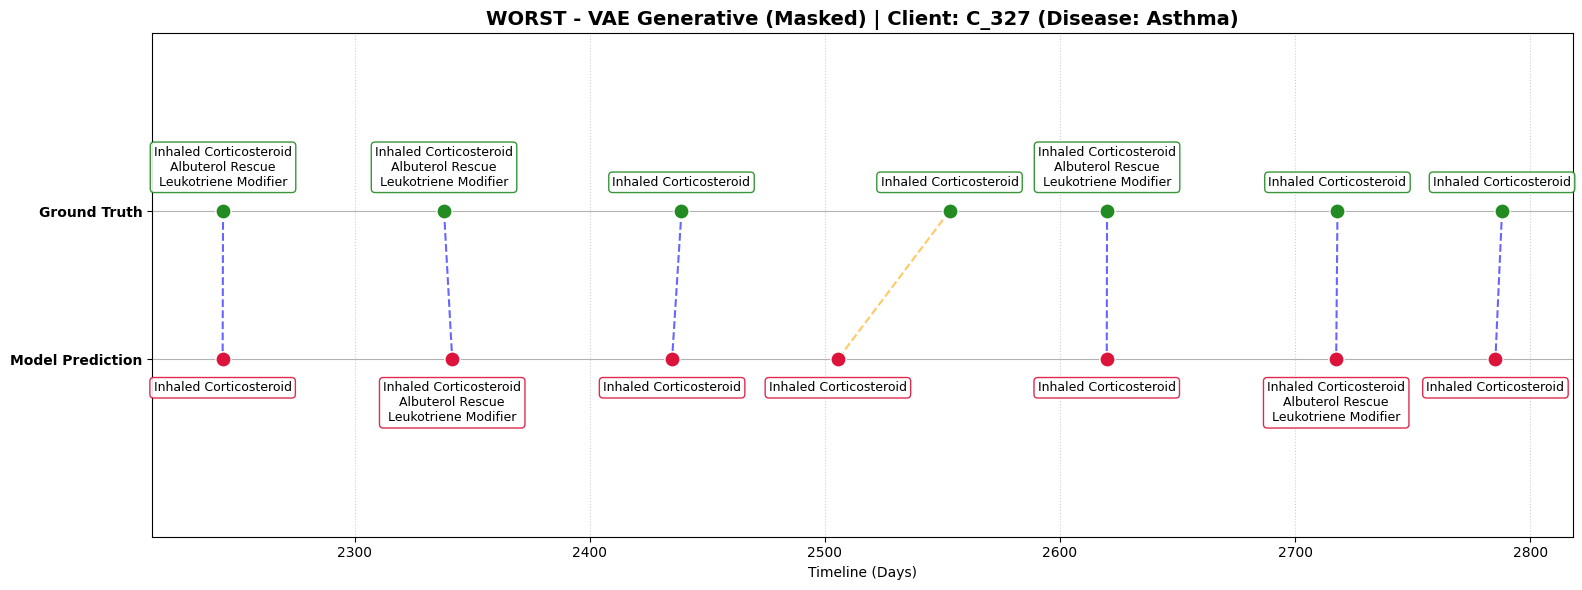

In [4]:
# ==========================================
# 6. PER-CLIENT ANALYSIS (BEST, MEDIAN, WORST)
# ==========================================

def analyze_client_performance(results):
    """
    Groups predictions by client_id, calculates individual IoU and Day Error,
    and returns the best, median 3, and worst clients.
    """
    pm, tm, pg, tg, cids, tdays = results
    unique_clients = np.unique(cids)
    
    client_metrics = []
    
    for cid in unique_clients:
        mask = (cids == cid)
        c_pm, c_tm = pm[mask], tm[mask]
        c_pg, c_tg = pg[mask], tg[mask]
        
        # Calculate IoU for this specific client
        preds_bin = (torch.sigmoid(c_pm) > 0.5).float()
        intersection = (preds_bin * c_tm).sum(dim=1)
        union = (preds_bin + c_tm).clamp(0, 1).sum(dim=1)
        iou = (intersection / (union + 1e-8)).mean().item()
        
        # Calculate Day Error for this specific client
        err = torch.abs(c_pg - c_tg).mean().item()
        
        client_metrics.append({
            'client_id': cid,
            'iou': iou,
            'err': err
        })
        
    # Sort clients: Primary by highest IoU (descending), Secondary by lowest Error (ascending)
    client_metrics.sort(key=lambda x: (-x['iou'], x['err']))
    
    best = client_metrics[0]
    worst = client_metrics[-1]
    
    n = len(client_metrics)
    mid = n // 2
    
    # Grab the 3 median clients (or less if the dataset is tiny)
    if n >= 3:
        medians = client_metrics[mid-1 : mid+2]
    else:
        medians = client_metrics
        
    return best, medians, worst


print("\n" + "="*50)
print("MASKED MODELS: BEST, MEDIAN, WORST CLIENT ANALYSIS")
print("="*50)

# We are only analyzing the masked configurations as requested
masked_configs = [
    ("Statistical Baseline (Masked)", res_stat_masked),
    ("Baseline LSTM (Masked)", res_lstm_masked),
    ("VAE Generative (Masked)", res_vae_masked)
]

for model_name, res in masked_configs:
    best, medians, worst = analyze_client_performance(res)
    
    print(f"\n--- {model_name} ---")
    print(f"🏆 BEST Client   : {best['client_id']} | IoU: {best['iou']:.2%} | Err: ±{best['err']:.2f} Days")
    for i, m in enumerate(medians):
        print(f"📊 MEDIAN {i+1} Client: {m['client_id']} | IoU: {m['iou']:.2%} | Err: ±{m['err']:.2f} Days")
    print(f"🚨 WORST Client  : {worst['client_id']} | IoU: {worst['iou']:.2%} | Err: ±{worst['err']:.2f} Days")

    # Combine into a list to iterate for plotting
    clients_to_visualize = [
        (best['client_id'], f"BEST - {model_name}"),
        (medians[0]['client_id'], f"MEDIAN 1 - {model_name}"),
        (medians[1]['client_id'], f"MEDIAN 2 - {model_name}"),
        (medians[2]['client_id'], f"MEDIAN 3 - {model_name}"),
        (worst['client_id'], f"WORST - {model_name}")
    ]

    # Render plots using your existing dynamic plotting function
    for cid, plot_title in clients_to_visualize:
        plot_client_comparison(
            cid, 
            [(res, plot_title)], 
            pipeline.test_seq_df, 
            pipeline.all_meds
        )